# Self-Supervised Pretraining & Fine-tuning Ablations

Reproduces the **SSL** panels of the DeepCell Types paper: the two-stage training schematics (Stage 1 masked-marker self-supervised pretraining; Stage 2 end-to-end fine-tune onto cell-type labels), the test-split **Frozen-CLS vs Pretrain + Fine-tune** metric bars (cell-type macro F1 + marker-positivity F1), the per-class Frozen-CLS-vs-Pretrain+FT comparison (paired bars and signed delta), and the masked-marker **pretext-task** diagnostic (does the SSL objective itself learn?).

All figures use the **Science Advances 2026** figure spec (via `dct_figures.style`). Per-class scores use the v10 held-out test split, hierarchical evaluation with per-(tissue, modality) IQR-fence cell-type abstention at **k = 0.2** (the paper headline operating point).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, json
from dct_figures import paths, style, colors, scoring
style.apply_style()

## Shared config

Vendored layout constants + the helper draw functions used by the panels below. `scoring.CT2IDX` replaces the workspace `TissueNetConfig.ct2idx`; the per-class panels score the prediction CSVs through the torch-free `scoring.score_csv` at the headline `abstention_k=0.2`.

In [2]:
from dct_figures.style import (
    PAL, COL_1_5, COL_2, MAX_HEIGHT,
    BAR_WIDTH, BAR_WIDTH_GROUP,
    style_ax, setup_perf_bar_axes,
    PERF_BAR_INCHES, PERF_BAR_PITCH_INCHES,
    FS_AXIS_TITLE, FS_AXIS_LABEL, FS_BODY, FS_TICK, FS_SMALL, FS_TINY,
)
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

ct2idx = scoring.CT2IDX
ZARR = paths.EXPANDED_TISSUENET_ZARR

FROZEN_CSV = paths.OUTPUT / 'final_frozen_cls_test_prediction.csv'
FT_CSV     = paths.OUTPUT / 'final_finetuned_test_prediction.csv'


def _rounded_box(ax, x, y, w, h, label, *, color, text_color='white',
                 fontsize=8.0, font_weight='600', linewidth=0.6):
    bbox = FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle='round,pad=0.04,rounding_size=0.18',
        facecolor=color, edgecolor=PAL['theme_dark'],
        linewidth=linewidth, zorder=3,
    )
    ax.add_patch(bbox)
    ax.text(x, y, label, ha='center', va='center', color=text_color,
            fontsize=fontsize, fontweight=font_weight, zorder=4)


def _arrow(ax, x0, y0, x1, y1, *, color=None, lw=0.9):
    color = color or PAL['dark']
    ax.add_patch(FancyArrowPatch(
        (x0, y0), (x1, y1), arrowstyle='-|>', mutation_scale=10,
        color=color, linewidth=lw, zorder=2,
    ))


def _setup_schematic_ax(ax, title):
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 6.5)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(title, fontsize=FS_AXIS_TITLE, fontweight='normal', pad=2,
                 color=PAL['dark'], loc='left', x=0.0)

## Stage 1 — masked-marker SSL pretraining schematic (`ssl_pretrain_schematic`)

caption: Schematic of Stage 1 masked-marker self-supervised pretraining (FOV markers → 30% mask → transformer → predict masked means).

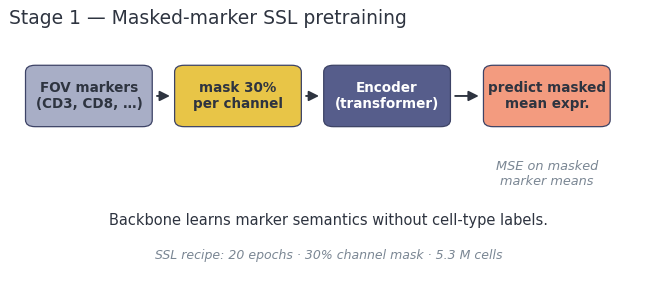

In [3]:
def draw_pretrain_schematic(ax):
    _setup_schematic_ax(ax, 'Stage 1 — Masked-marker SSL pretraining')
    box_w, box_h = 2.3, 1.55
    y = 4.7
    boxes = [
        (1.50, 'FOV markers\n(CD3, CD8, …)', PAL['theme_light'], PAL['dark']),
        (4.30, 'mask 30%\nper channel', PAL['yellow'], PAL['dark']),
        (7.10, 'Encoder\n(transformer)', PAL['theme'], 'white'),
        (10.10, 'predict masked\nmean expr.', PAL['salmon'], PAL['dark']),
    ]
    for x, lab, fill, txt in boxes:
        _rounded_box(ax, x, y, box_w, box_h, lab, color=fill,
                     text_color=txt, fontsize=6.5)
    for (x0, *_), (x1, *_) in zip(boxes, boxes[1:]):
        _arrow(ax, x0 + box_w / 2 + 0.05, y, x1 - box_w / 2 - 0.05, y)
    ax.text(10.10, 3.0, 'MSE on masked\nmarker means', ha='center', va='top',
            fontsize=6.2, color=PAL['gray'], style='italic')
    ax.text(6.0, 1.6,
            'Backbone learns marker semantics without cell-type labels.',
            ha='center', va='top', fontsize=7.0, color=PAL['dark'])
    ax.text(6.0, 0.65,
            'SSL recipe: 20 epochs · 30% channel mask · 5.3 M cells',
            ha='center', va='top', fontsize=6.0, color=PAL['gray'],
            style='italic')

fig, ax = plt.subplots(figsize=(COL_1_5, 2.0))
draw_pretrain_schematic(ax)
fig.tight_layout()
plt.show()

## Stage 2 — end-to-end fine-tune schematic (`ssl_finetune_schematic`)

caption: Schematic of Stage 2 end-to-end fine-tune from the pretrained backbone onto cell-type labels.

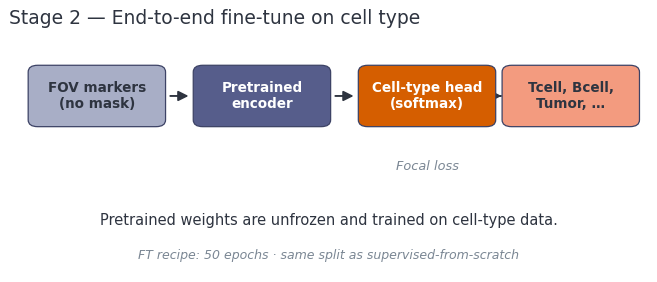

In [4]:
def draw_finetune_schematic(ax):
    _setup_schematic_ax(ax, 'Stage 2 — End-to-end fine-tune on cell type')
    box_w, box_h = 2.5, 1.55
    y = 4.7
    boxes = [
        (1.65, 'FOV markers\n(no mask)', PAL['theme_light'], PAL['dark']),
        (4.75, 'Pretrained\nencoder', PAL['theme'], 'white'),
        (7.85, 'Cell-type head\n(softmax)', PAL['red'], 'white'),
        (10.55, 'Tcell, Bcell,\nTumor, …', PAL['salmon'], PAL['dark']),
    ]
    for x, lab, fill, txt in boxes:
        _rounded_box(ax, x, y, box_w, box_h, lab, color=fill,
                     text_color=txt, fontsize=6.5)
    for (x0, *_), (x1, *_) in zip(boxes, boxes[1:]):
        _arrow(ax, x0 + box_w / 2 + 0.05, y, x1 - box_w / 2 - 0.05, y)
    ax.text(7.85, 3.0, 'Focal loss', ha='center', va='top',
            fontsize=6.2, color=PAL['gray'], style='italic')
    ax.text(6.0, 1.6,
            'Pretrained weights are unfrozen and trained on cell-type data.',
            ha='center', va='top', fontsize=7.0, color=PAL['dark'])
    ax.text(6.0, 0.65,
            'FT recipe: 50 epochs · same split as supervised-from-scratch',
            ha='center', va='top', fontsize=6.0, color=PAL['gray'],
            style='italic')

fig, ax = plt.subplots(figsize=(COL_1_5, 2.0))
draw_finetune_schematic(ax)
fig.tight_layout()
plt.show()

## Test-split metric bars (`ssl_metric_bars`)

caption: Test-split cell-type macro F1 + MP F1 — Frozen-CLS vs Pretrain + Fine-tune (both share the SSL backbone).

Reads `ssl_ablation.csv` (self-contained: one row per condition with the `cell_type_macro_f1` and `mp_f1` columns the headline panels also use).

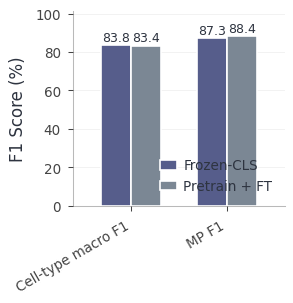

In [5]:
METRICS = [
    ('cell_type_macro_f1', 'Cell-type macro F1'),
    ('mp_f1',              'MP F1'),
]
CONDITIONS = ('scratch', 'ssl_then_ft')
COND_LABELS = {'scratch': 'Frozen-CLS', 'ssl_then_ft': 'Pretrain + FT'}

ablation = pd.read_csv(paths.need(paths.OUTPUT / 'ssl_ablation.csv')).set_index('condition')
means = {c: [float(ablation.loc[c, k]) for k, _ in METRICS] for c in CONDITIONS}

fig, ax = plt.subplots(figsize=(COL_1_5, 3.0))
x, bar_w = setup_perf_bar_axes(fig, ax, len(METRICS),
                               target_bar_inches=PERF_BAR_INCHES,
                               target_pitch_inches=2 * PERF_BAR_PITCH_INCHES)
cond_colors = [PAL['theme'], PAL['gray']]
all_vals = []
for i, cond in enumerate(CONDITIONS):
    offset = (-0.5 + i) * bar_w
    vals = np.array([means[cond][mi] for mi in range(len(METRICS))]) * 100.0
    all_vals.append(vals)
    ax.bar(x + offset, vals, width=bar_w, color=cond_colors[i],
           edgecolor='white', linewidth=0.8, zorder=3, label=COND_LABELS[cond])
    for xi, v in zip(x + offset, vals):
        if np.isfinite(v):
            ax.text(xi, v + 0.5, f'{v:.1f}', ha='center', va='bottom',
                    fontsize=FS_SMALL, color=PAL['dark'])

ax.set_xticks(x)
ax.set_xticklabels([m[1] for m in METRICS], fontsize=FS_TICK, rotation=30, ha='right')
ax.set_ylabel('F1 Score (%)')
flat = np.concatenate(all_vals); flat = flat[np.isfinite(flat)]
ax.set_ylim(0, (flat.max() if flat.size else 1.0) * 1.15)
ax.legend(fontsize=FS_TICK, loc='lower right', frameon=False,
          handlelength=1.2, columnspacing=1.2)
style_ax(ax)
plt.show()

## Per-class scoring

Score the Frozen-CLS and Pretrain+Finetune test-prediction CSVs through the torch-free `scoring.score_csv` at the headline `abstention_k=0.2` (per-(tissue, modality) IQR-fence cell-type abstention). Both per-class panels below reuse these scored results.

In [6]:
FROZEN_LABEL = 'Frozen-CLS (final ckpt)'
FT_LABEL = 'Pretrain + Finetune (epoch 30)'

frozen = scoring.score_csv(paths.need(FROZEN_CSV), ct2idx,
                           abstention_k=0.2, zarr_path=ZARR)
ft = scoring.score_csv(paths.need(FT_CSV), ct2idx,
                       abstention_k=0.2, zarr_path=ZARR)
print(f"Frozen-CLS:    macro_f1={frozen['macro_f1']:.2f}  coverage={frozen['coverage']*100:.1f}%")
print(f"Pretrain+FT:   macro_f1={ft['macro_f1']:.2f}  coverage={ft['coverage']*100:.1f}%")

Frozen-CLS:    macro_f1=83.84  coverage=82.1%
Pretrain+FT:   macro_f1=83.37  coverage=82.3%


## Per-class paired bars (`per_class_pft_vs_frozen`)

caption: Per-class macro F1, paired bars — Frozen-CLS vs Pretrain+Finetune.

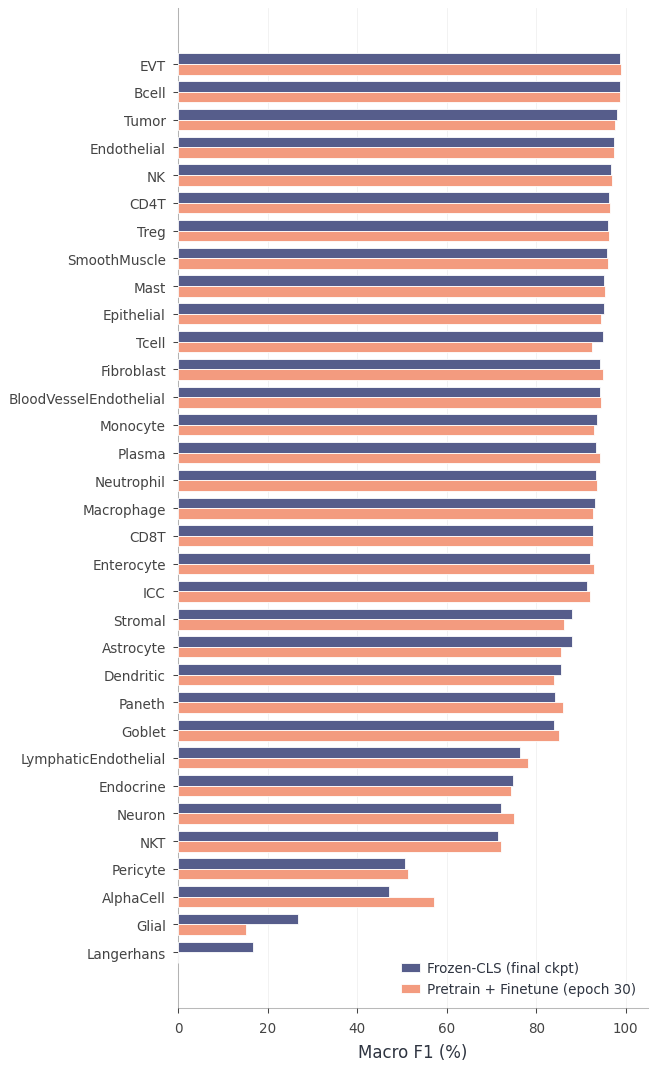

In [7]:
classes = sorted(set(frozen['per_class_f1']) & set(ft['per_class_f1']),
                 key=lambda c: frozen['per_class_f1'][c])
fr = np.array([frozen['per_class_f1'][c] for c in classes])
fv = np.array([ft['per_class_f1'][c] for c in classes])
n = len(classes)
y = np.arange(n)
height = BAR_WIDTH_GROUP
fig, ax = plt.subplots(figsize=(COL_1_5, min(MAX_HEIGHT, max(4.5, n * 0.22))))
ax.barh(y + height / 2, fr, height, color=PAL['blue'], edgecolor='white',
        linewidth=0.4, label=FROZEN_LABEL, zorder=3)
ax.barh(y - height / 2, fv, height, color=PAL['salmon'], edgecolor='white',
        linewidth=0.4, label=FT_LABEL, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(classes, fontsize=FS_TICK)
ax.set_xlabel('Macro F1 (%)')
ax.set_xlim(0, 105)
ax.legend(loc='lower right', framealpha=0.95, fontsize=FS_TICK)
style_ax(ax, grid_axis='x')
fig.tight_layout()
plt.show()

## Per-class delta (`per_class_delta_pft_vs_frozen`)

caption: Per-class macro F1 delta (Pretrain+FT − Frozen-CLS).

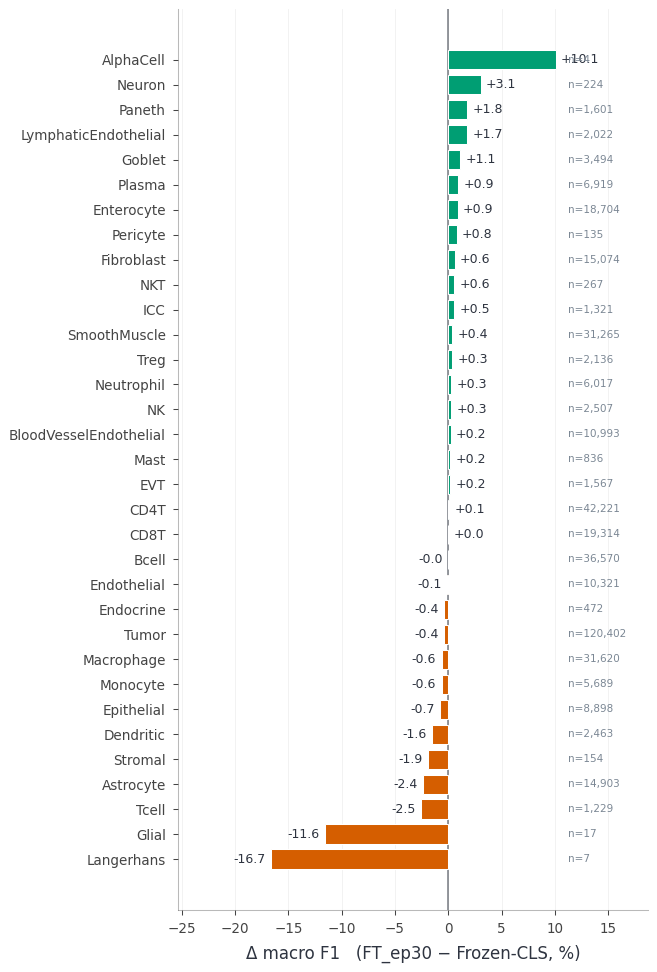

In [8]:
classes = sorted(set(frozen['per_class_f1']) & set(ft['per_class_f1']),
                 key=lambda c: ft['per_class_f1'][c] - frozen['per_class_f1'][c])
deltas = np.array([ft['per_class_f1'][c] - frozen['per_class_f1'][c]
                   for c in classes])
supports = np.array([frozen['per_class_support'].get(c, 0) for c in classes])
n = len(classes)
fig, ax = plt.subplots(figsize=(COL_1_5, min(MAX_HEIGHT, max(4.5, n * 0.20))))
bar_colors = [PAL['red'] if d < 0 else PAL['green'] for d in deltas]
ax.barh(range(n), deltas, color=bar_colors, edgecolor='white',
        linewidth=0.5, height=BAR_WIDTH, zorder=3)
ax.set_yticks(range(n))
ax.set_yticklabels(classes, fontsize=FS_TICK)
for i, (d, s) in enumerate(zip(deltas, supports)):
    ax.text(d + (0.5 if d >= 0 else -0.5), i, f'{d:+.1f}', va='center',
            ha='left' if d >= 0 else 'right', fontsize=FS_SMALL, color=PAL['dark'])
    ax.text(deltas.max() + 1.2, i, f'n={s:,}', va='center',
            fontsize=FS_TINY, color=PAL['gray'])
ax.axvline(0, color=PAL['dark'], linewidth=0.8, alpha=0.6)
ax.set_xlabel('Δ macro F1   (FT_ep30 − Frozen-CLS, %)')
xlim_pad = max(abs(deltas.max()), abs(deltas.min())) * 0.22 + 5.0
ax.set_xlim(deltas.min() - xlim_pad, deltas.max() + xlim_pad)
style_ax(ax, grid_axis='x')
fig.tight_layout()
plt.show()

## Pretext-task diagnostic (`ssl_pretext_task`)

caption: Does the masked-marker pretext task itself learn? Marker-positivity macro F1 (learned per-marker thresholds, 64 markers with support; house MP metric) on a 50k-cell sample of the v10 held-out test split. MASKED channels (marker image hidden → inferred from the other markers) reach 73.2% F1, close to the UNMASKED visible-image reference (82.7%) and far above an untrained random-init backbone (27.0%) — the SSL objective captures real cross-marker structure. Pretrain backbone deepcell-types_2026-05-17_pretrain.pt, epoch 15.

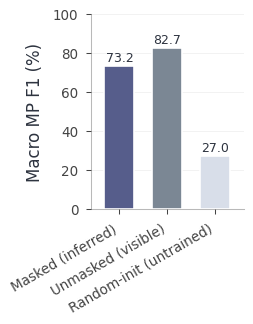

In [9]:
ORDER = ('masked', 'unmasked', 'random')
PRETEXT_COLORS = {
    'masked': PAL['theme'],
    'unmasked': PAL['gray'],
    'random': PAL['light_gray'],
}
pretext = json.load(open(paths.need(paths.OUTPUT / 'ssl_pretext_metrics.json')))
cond = pretext['conditions']

fig, ax = plt.subplots(figsize=(COL_1_5, 3.0))
x, bar_w = setup_perf_bar_axes(fig, ax, len(ORDER),
                               target_bar_inches=PERF_BAR_INCHES,
                               target_pitch_inches=PERF_BAR_PITCH_INCHES)
vals = np.array([cond[k]['macro_f1'] for k in ORDER]) * 100.0
bar_cols = [PRETEXT_COLORS[k] for k in ORDER]
ax.bar(x, vals, width=bar_w, color=bar_cols, edgecolor='white',
       linewidth=0.8, zorder=3)
for xi, v in zip(x, vals):
    ax.text(xi, v + 0.8, f'{v:.1f}', ha='center', va='bottom',
            fontsize=FS_SMALL, color=PAL['dark'])
ax.set_xticks(x)
ax.set_xticklabels([cond[k]['label'] for k in ORDER], fontsize=FS_TICK,
                   rotation=30, ha='right')
ax.set_ylabel('Macro MP F1 (%)')
ax.set_ylim(0, max(vals.max() * 1.18, 100))
style_ax(ax)
plt.show()